# TxGNN — Dual-Ranking Ensemble (Option A)

Does scoring a drug–disease pair from the **drug side** as well as the disease side make
TxGNN's zero-shot predictions **less seed-sensitive**, without costing accuracy?

TxGNN pools a disease with its top-*k* mechanistically-similar diseases and gates the
result by the disease's rarity. This notebook adds the mirror-image operation on the
drug side and scores every pair two independent ways:

| | pooled end | plain end | code path |
|---|---|---|---|
| **`p_A`** | disease `h_i^hat` | drug `h_j` | original TxGNN, untouched |
| **`p_B`** | drug `h_j^hat` | disease `h_i` | new, `score_path='B'` |

then fuses the two ranked candidate lists per disease. `p_A` is the baseline; the claim
under test is that the **fused** ranking has lower cross-seed variance at equal or better
mean AUPRC. A fusion that buys stability by regressing toward a worse mean is not a win,
so §9 reports mean and variance side by side and never one without the other.

**Reference**: Huang et al., *A foundation model for clinician-centered drug repurposing*,
Nature Medicine (2024). Baseline reproduction: [`TxGNN_PyG_Train_Eval.ipynb`](TxGNN_PyG_Train_Eval.ipynb).

---

## What this notebook runs

| § | Stage | Produces |
|---|---|---|
| 1–2 | Environment & configuration | one `CFG` dict driving everything |
| 3 | Data & the `anemia` disease-area split | `kg_directed.csv`, train/valid/test, PyG graph |
| 4 | The drug-side module | signature coverage, top-*k* cache, gate distribution |
| 5 | **Baseline-integrity check** | proof that `p_A` is bit-for-bit unchanged |
| 6 | One seed end to end | `p_A` / `p_B` raw scores + the A↔B correlation kill criterion |
| 7 | Rank-average fusion | per-disease AUPRC for 3 variants |
| 8 | **Multi-seed sweep** (5 init seeds) | tidy per-disease/per-seed/per-variant table |
| 9 | Analysis | mean vs variance, paired deltas, degree-stratified |
| 10 | *Stage 2* — learned fusion | scalar + MLP late fusion (flag-gated off) |
| 11 | *Stage 3* — variant (b) ablation | `drug_drug` + `drug_protein` profile (flag-gated off) |
| 12 | Design decisions & caveats | every judgement call, and what this does not show |

## Reading order

§5 is not optional. Everything downstream compares against `p_A`, so if the drug module
perturbs the baseline in any way the comparison is meaningless. §5 proves it doesn't,
and it runs in seconds.

§6 ends with a **kill criterion**. If `p_B` turns out to be a monotone restatement of
`p_A`, there is nothing for a fusion to combine and the remaining seeds are wasted GPU
time. Check it before enabling §8.

---
## 0 · Design decisions, up front

Same convention as the baseline notebook: every place the library did not decide for me.
`DR` numbers are this notebook's; `D` numbers refer to
[`TxGNN_PyG_Train_Eval.ipynb`](TxGNN_PyG_Train_Eval.ipynb) §0.

| # | Decision | Why |
|---|---|---|
| **DR1** | `p_B` is a **read-out**, not a trained path. One training run per seed on the unmodified path A; `p_B` is computed from that same encoder at eval time | The bit-for-bit constraint on `p_A`. If `p_B` contributed to the loss the encoder would differ and `p_A` would no longer be the baseline. Drug pooling is parameter-free (the rarity gate is `utils.exponential`), so `p_B` is fully determined by the trained encoder. `train_score_path` is left as a one-line follow-up, not run here |
| **DR2** | Drug module adds **zero** `nn.Parameter`s | Any new parameter would consume torch RNG in `DistMultPredictor.__init__`, shifting every subsequent draw — including `w_rels` and the frozen node embeddings. `W_gate['drug']` already exists in the baseline (`model.py:52-56`). Verified in §5 |
| **DR3** | Learned fusion lives **outside** the model, fitted post-hoc on saved scores | Same reason as DR2, plus it keeps fusion swappable without retraining |
| **DR4** | Drug signature variant **(a) `drug_protein`-only is primary**; (b) `drug_drug + drug_protein` is an ablation (§11) | `drug_drug` mean degree ≈ 336 vs `drug_protein` ≈ 3.2. Concatenated, the cosine is dominated by co-prescription structure, which is a prescribing artifact rather than a mechanism. Quantified in §4.2 |
| **DR5** | Self-pooling is masked **explicitly**, not by the disease side's shape heuristic | Held-out diseases are absent from the key set so they never self-match. Drugs are *not* held out by a disease-area split, so most query drugs **are** keys and would self-match at cosine 1.0 — with `k=3`, one of three slots. `model.py:234`'s `src_h.shape[0] == src_h_keys.shape[0]` test does not catch this |
| **DR6** | Drugs with an **empty signature** keep their own embedding (`c_j` forced to 0) | 21% of drugs have no `drug_protein` edge. Their profile is all-zero, `sim_matrix`'s `eps` guard returns a zero row, `F.normalize` returns zeros, and `h_j^hat` collapses to `(1-c_j)·h_j` — a silent shrinkage toward the origin, not a neutral fallback. §4.2 counts them |
| **DR7** | Top-*k* neighbours cached as **indices + coefficients**, computed once | The similarity matrix is a function of graph structure only and never changes during training. Storing indices instead of the dense matrix drops the cache from ~113 MB to ~200 KB and makes the forward pass a gather |
| **DR8** | Query rows built for **all** drugs, not just drugs with DD edges | `get_scores_disease` scores every drug in the KG. Restricting the cache to key drugs would fire the disease side's on-the-fly `except` branch (`model.py:200-224`) for ~6k drugs per disease per relation |
| **DR9** | Split = **`anemia`**, split seed fixed, **init seed** varied | A disease-area split's test disease set is fixed by the ontology (`utils.py:392-396`), so the same diseases are scored under every seed and per-disease variance is well defined. Under `complex_disease` the fold seed shuffles *which* diseases are held out, so per-disease cross-seed variance is not computable at all. See §3.2 |
| **DR10** | Degrees computed **here**, not read from `disease_centric_evaluation` | The library's per-disease dict has no degree fields — `AUPRC/AUROC/Recall@k/MRR/AP/Enrichment/#Pos/Prediction/Labels` and nothing else |
| **DR11** | `simulate_random=False` throughout | It drives `Enrichment@k` with 500 unseeded `np.random.shuffle` calls per disease (baseline **D12**) — pure cost and pure noise here |
| **DR12** | Fused AUPRC recomputed locally, and asserted equal to the library's for `p_A` | The library computes AUPRC inside `calculate_metrics`, which takes no injected scores. `dual_rank.filter_candidates` mirrors its masking line for line; `assert_matches_library` fails the run if it ever drifts |
| **DR13** | Learned fusion fitted on **validation** diseases | Fitting on test diseases leaks. The honest cost: in a disease-area split the validation diseases come from the complement area, so their degree distribution differs from the held-out area |
| **DR15** | Evaluation restricted to test diseases with **zero** training drug edges | A disease-area split is not uniformly zero-shot: the ontology holdout and `disease_files/<area>.csv` disagree, so a disease can reach `df_test` through the random 5% fraction while keeping every training edge. On `anemia` that is 2 of 15. Measured and excluded in §3.4; applies to any disease-area result from this repo, not just this experiment |
| **DR14** | `exp_lambda_drug` is a **separate** hyperparameter, default 0.7 | 0.7 is the disease-side value; there is no reason to think it transfers. It is a starting point, not a claim. §10.3 sweeps it — cheap, because changing it needs no retraining |

### What changed under `pyg_implementation/txgnn/`

Unlike the baseline notebook, this one *did* require library changes. All additive and
flag-gated; with `drug_proto=False` (the default) every code path is byte-identical to
before.

| File | Change |
|---|---|
| `utils.py` | `+ obtain_drug_profile()`, `+ build_drug_profile_matrix()`. No existing line touched |
| `model.py` | `DistMultPredictor.__init__` gains 4 kwargs + a drug-side cache block; `forward` gains a `score_path` guard on two existing `if`s and one new `elif` branch; `HeteroRGCN.__init__` threads the kwargs |
| `TxGNN.py` | `model_initialize` gains 4 kwargs; `self.config` now records `exp_lambda` (**pre-existing bug** — it was omitted, so `load_pretrained` silently reverted a non-default value to 0.7) plus the new drug keys; `+ set_score_path()` |
| `dual_rank.py` | **new** — candidate filtering, fusion rules, per-disease evaluation, the library-equivalence assertion |

---
## 1 · Environment

In [1]:
import os, sys, json, time, math, pickle, random, shutil, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / 'pyg_implementation'))

import torch_geometric
from txgnn import TxData, TxGNN, TxEval
from txgnn import dual_rank as dr
from txgnn.utils import convert2str, obtain_disease_profile
from torch_geometric.utils import degree

print('python          ', sys.version.split()[0])
print('torch           ', torch.__version__)
print('torch-geometric ', torch_geometric.__version__)
print('cuda available  ', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device          ', torch.cuda.get_device_name(0))

python           3.12.13
torch            2.6.0+cu118
torch-geometric  2.8.0
cuda available   True
device           NVIDIA GeForce RTX 4060 Ti


In [2]:
def set_all_seeds(seed: int):
    '''Seed every RNG the training path touches.

    Note what this does NOT buy (baseline notebook §11.5): torch.manual_seed(0) runs at
    TxGNN import time so RNG state depends on import order, and torch_scatter's
    reduce='mean' uses non-deterministic CUDA atomics. Bit-exact reproduction across
    machines is not achievable; bit-exact p_A-vs-p_A *within* a process is, and that is
    what §5 checks.
    '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)
if DEVICE == 'cpu':
    print('WARNING: CPU-only. Use PROFILE = "smoke"; the full profile is not practical here.')

device: cuda:0


---
## 2 · Configuration

`MODEL_CFG` is copied verbatim from `pyg_implementation/reproduce/train.py` (baseline
**D2**) so the encoder is the paper's. The `drug_*` keys are the only additions, and
they are inert unless `drug_proto=True`.

In [3]:
PROFILE     = 'full'      # 'smoke' to validate the plumbing, 'full' to produce results
SPLIT       = 'cardiovascular'     # disease-area holdout, 65 held-out diseases (DR9)
SPLIT_SEED  = 1            # FIXED. varies train/valid only; test diseases are ontology-fixed
INIT_SEEDS  = [1, 2, 3, 4, 5]   # what actually varies: model initialisation

# stage gates -- see the reading order note at the top
RUN_MULTISEED     = True   # §8   the expensive one
RUN_LEARNED_FUSION = True  # §10  stage 2
RUN_LAMBDA_SWEEP   = False  # §10.3
RUN_VARIANT_B      = True  # §11  stage 3

# -- encoder: verbatim from reproduce/train.py (D2) --------------------------------
MODEL_CFG = dict(
    n_hid       = 100,
    n_inp       = 100,
    n_out       = 100,
    proto       = True,                  # disease-side similarity pooling
    proto_num   = 3,                     # k similar diseases
    attention   = False,
    sim_measure = 'all_nodes_profile',   # disease signature: disease + gene/protein blocks
    agg_measure = 'rarity',              # c_i = 0.7*exp(-0.7*deg_i) + 0.2
    exp_lambda  = 0.7,
)

# -- drug side: the new module ------------------------------------------------------
DRUG_CFG = dict(
    drug_proto       = True,
    drug_proto_num   = 3,                      # k similar drugs, matched to the disease side
    drug_sim_measure = 'drug_protein_profile', # variant (a), PRIMARY (DR4)
    exp_lambda_drug  = 0.7,                    # SEPARATE hyperparameter (DR14)
)

_PROFILES = {
    'smoke': dict(
        pretrain = dict(n_epoch=0,  learning_rate=1e-3, batch_size=1024, train_print_per_n=50),
        finetune = dict(n_epoch=20, learning_rate=5e-4, train_print_per_n=5, valid_per_n=10),
    ),
    'full': dict(
        pretrain = dict(n_epoch=1,    learning_rate=1e-3, batch_size=1024, train_print_per_n=100),
        finetune = dict(n_epoch=1000, learning_rate=5e-4, train_print_per_n=50, valid_per_n=20),
    ),
}

CFG = dict(profile=PROFILE, split=SPLIT, split_seed=SPLIT_SEED, model=MODEL_CFG,
           drug=DRUG_CFG, **_PROFILES[PROFILE])

DATA_FOLDER = REPO_ROOT / 'data'
OUT_ROOT    = REPO_ROOT / 'results' / 'dual_rank' / f'{SPLIT}_splitseed{SPLIT_SEED}_{PROFILE}'
OUT_ROOT.mkdir(parents=True, exist_ok=True)

DD_REL = ['indication', 'contraindication', 'off-label use']

print(json.dumps({k: v for k, v in CFG.items() if k != 'model'}, indent=2, default=str))
print('\noutput ->', OUT_ROOT)
if PROFILE == 'smoke':
    print('\n>>> SMOKE PROFILE: pretraining is skipped, numbers are plumbing only. <<<')

{
  "profile": "full",
  "split": "cardiovascular",
  "split_seed": 1,
  "drug": {
    "drug_proto": true,
    "drug_proto_num": 3,
    "drug_sim_measure": "drug_protein_profile",
    "exp_lambda_drug": 0.7
  },
  "pretrain": {
    "n_epoch": 1,
    "learning_rate": 0.001,
    "batch_size": 1024,
    "train_print_per_n": 100
  },
  "finetune": {
    "n_epoch": 1000,
    "learning_rate": 0.0005,
    "train_print_per_n": 50,
    "valid_per_n": 20
  }
}

output -> /home/dsls/Desktop/projects/BardiaSabbagh/txgnn-refactor/results/dual_rank/cardiovascular_splitseed1_full


---
## 3 · Data and the `anemia` split

### 3.1 Wiring PrimeKG

`TxData` wants a flat folder with `kg.csv`, `node.csv` (**tab**-separated), `edges.csv`.
The repo keeps the dump in `data/kg/` with `nodes.csv` (plural, comma-separated). Same
reconciliation as the baseline notebook (**D1**) — hard-link where possible, rewrite the
node table as TSV. Disease-area splits need `node.csv` and `edges.csv`; `complex_disease`
does not, which is why this cell matters more here than there.

In [4]:
PRIMEKG_DIR = DATA_FOLDER / 'kg'
DATA_FOLDER.mkdir(parents=True, exist_ok=True)

def _link_or_copy(src, dst):
    if dst.exists():
        print(f'  present   {dst.name}'); return
    if not src.exists():
        print(f'  MISSING   {src}  -> TxData will download it'); return
    try:
        os.link(src, dst); how = 'hardlink'
    except OSError:
        shutil.copyfile(src, dst); how = 'copy'
    print(f'  {how:9s} {src.name} -> {dst.name}')

def _to_tsv(src, dst):
    if dst.exists():
        print(f'  present   {dst.name}'); return
    if not src.exists():
        print(f'  MISSING   {src}'); return
    pd.read_csv(src, low_memory=False).to_csv(dst, sep='\t', index=False)
    print(f'  tsv       {src.name} -> {dst.name}')

print('Wiring PrimeKG into', DATA_FOLDER)
_link_or_copy(PRIMEKG_DIR / 'kg.csv',    DATA_FOLDER / 'kg.csv')
_link_or_copy(PRIMEKG_DIR / 'edges.csv', DATA_FOLDER / 'edges.csv')
_to_tsv      (PRIMEKG_DIR / 'nodes.csv', DATA_FOLDER / 'node.csv')

assert (DATA_FOLDER / 'disease_files' / f'{SPLIT}.csv').exists(), \
    f'data/disease_files/{SPLIT}.csv missing'
n_area = len(pd.read_csv(DATA_FOLDER / 'disease_files' / f'{SPLIT}.csv'))
print(f'\ndisease area "{SPLIT}": {n_area} diseases in the holdout list')

Wiring PrimeKG into /home/dsls/Desktop/projects/BardiaSabbagh/txgnn-refactor/data
  present   kg.csv
  present   edges.csv
  present   node.csv

disease area "cardiovascular": 287 diseases in the holdout list


### 3.2 Why a disease-area split, and why the seed means something different here

This is the load-bearing reason for **DR9**, and it is easy to get wrong.

`utils.create_fold` routes disease-area splits to its `else` branch (`utils.py:392-396`):

```python
train_val = df[df.split == 'train'].reset_index(drop = True)
test      = df[df.split == 'test'].reset_index(drop = True)
out       = random_fold(train_val, fold_seed, [0.875, 0.125, 0.0])
out['test'] = test
```

The **test set is fixed by the Disease Ontology**, and `fold_seed` only reshuffles the
train/valid partition of everything else. So the same 65 diseases are scored under every
seed and per-disease variance is well defined.

Contrast `complex_disease`, where `fold_seed` shuffles *which* diseases are held out
(`utils.py:200-201`) — different seeds barely share test diseases, and a per-disease
cross-seed variance cannot be computed at all. The existing 5-run sweep in
`results/multiseed_complex_disease_full.csv` is a 5-**split** CI for that reason.

So in this notebook there are two distinct knobs and they must not be conflated:

| knob | what it changes | held at |
|---|---|---|
| `SPLIT_SEED` (`prepare_split(seed=…)`) | the **data** — train/valid partition of non-test edges | fixed at 1 |
| `INIT_SEEDS` (`set_all_seeds` before `model_initialize`) | the **model** — frozen node embeddings, `w_rels`, negative sampling | varied, 1–5 |

The library has no model-seed argument: `TxData.prepare_split(seed=…)` reaches only
`create_fold`, and `TxGNN.py:33` calls `torch.manual_seed(0)` once at import. Calling
`set_all_seeds` before `model_initialize` is the whole mechanism, and it touches nothing
inside `pyg_implementation/`.

### 3.3 Build the split

First run writes `data/anemia_kg/kg_directed.csv` (10–30 min) and
`data/anemia_1/{train,valid,test}.csv`. Both are cached.

In [5]:
set_all_seeds(SPLIT_SEED)
t0 = time.time()

txdata = TxData(data_folder_path=str(DATA_FOLDER))
txdata.prepare_split(split=SPLIT, seed=SPLIT_SEED, no_kg=False)

print('\nprepare_split took %.1f s' % (time.time() - t0))

G = txdata.G
print('\nnode types :', len(G.node_types))
print('edge types :', len(G.edge_types))
print('train edges: %s' % f'{sum(G[et].num_edges for et in G.edge_types):,}')

test_dd = txdata.df_test[txdata.df_test.relation.isin(['rev_' + r for r in DD_REL])]
print('\nheld-out diseases per relation:')
for r in DD_REL:
    n = test_dd[test_dd.relation == 'rev_' + r].x_idx.nunique()
    print(f'   {r:<18} {n:>4}')
print('   %-18s %4d  (union)' % ('', test_dd.x_idx.nunique()))

Found local copy...
Found local copy...
Found local copy...
Found saved processed KG... Loading...
Splits detected... Loading splits....
Creating PyG graph....
Done!

prepare_split took 8.3 s

node types : 10
edge types : 50
train edges: 6,894,626

held-out diseases per relation:
   indication           46
   contraindication     95
   off-label use        31
                       106  (union)


### 3.4 Zero-shot sanity check — and the subset that actually is zero-shot

A disease-area split is **not uniformly zero-shot**, which is easy to miss and quietly
corrupts a per-disease variance study. Two different disease lists are in play:

| used by | list |
|---|---|
| `utils.preprocess_kg` → `DataSplitter.get_test_kg_for_disease` | descendants of the area's **Disease Ontology** id (`name2id`, e.g. anemia = DOID:2355) |
| `utils.process_disease_area_split` (`utils.py:1057`) | `data/disease_files/<area>.csv` |

They do not agree. A disease in the CSV but outside the ontology-derived set keeps **all**
its training drug edges — and because the split also sweeps in a random `test_size=0.05`
fraction of the whole KG, a few of that disease's edges can still land in `df_test`. It
then looks like a held-out disease while being fully trained on.

Measured on `anemia`, split seed 1: **15** diseases have test drug–disease edges, of which
**2** also have training edges (208 train vs 20 test). Those two are not zero-shot and are
excluded below; the remaining 13 are.

This is a property of the library's disease-area protocol, not of the drug-side module —
it applies to any disease-area result produced from this repo.

So the check below does not assert "no disease leaks". It **partitions** the test diseases
and defines `ZERO_SHOT_IDS`, which every evaluation downstream is restricted to via
`dual_rank.evaluate_variants(keep_ids=…)`.

In [6]:
DD_REV = ['rev_' + r for r in DD_REL]

_tr = txdata.df_train[txdata.df_train.relation.isin(DD_REV)][['relation', 'x_idx', 'y_idx']]
_te = txdata.df_test [txdata.df_test .relation.isin(DD_REV)][['relation', 'x_idx', 'y_idx']]

test_dis  = set(_te.x_idx.unique())
train_dis = set(_tr.x_idx.unique())
leak_dis  = test_dis & train_dis
clean_idx = sorted(test_dis - train_dis)

# an identical (relation, disease, drug) triple in both splits would mean the dedup in
# preprocess_kg failed -- a different and much worse problem than the list mismatch
_dup = set(map(tuple, _tr.values)) & set(map(tuple, _te.values))
assert not _dup, ('%d identical triples in BOTH train and test -- preprocess_kg dedup '
                  'failed, the split is broken' % len(_dup))

print('test diseases with drug-disease edges : %d' % len(test_dis))
print('  genuinely zero-shot (0 train edges) : %d' % len(clean_idx))
print('  NOT zero-shot, excluded             : %d' % len(leak_dis))
if leak_dis:
    print('    their train edges: %d   test edges: %d'
          % (len(_tr[_tr.x_idx.isin(leak_dis)]), len(_te[_te.x_idx.isin(leak_dis)])))

assert clean_idx, 'no zero-shot diseases survive -- pick a different area (see 3.4b)'

ZERO_SHOT_IDS = None   # filled in after idx2id_disease is built, in 3.5
test_disease_idx = set(clean_idx)

print('\nper relation, zero-shot diseases only:')
for r in DD_REL:
    n = _te[(_te.relation == 'rev_' + r) & (_te.x_idx.isin(clean_idx))].x_idx.nunique()
    print('   %-18s %4d' % (r, n))

if len(clean_idx) < 25:
    print('\n>>> WARNING: %d diseases is thin for the degree-stratified analysis in '
          '§9.3.' % len(clean_idx))
    print('>>> Run 3.4b and consider a larger area before spending seeds.')

test diseases with drug-disease edges : 106
  genuinely zero-shot (0 train edges) : 91
  NOT zero-shot, excluded             : 15
    their train edges: 1081   test edges: 91

per relation, zero-shot diseases only:
   indication           41
   contraindication     81
   off-label use        28


### 3.4b Choosing an area — how many *treated* diseases does each one have?

`disease_files/<area>.csv` counts diseases in the ontology, not diseases with drug edges.
`anemia` lists 65 but only ~15 have any drug–disease edge in PrimeKG, and only 13 of those
survive §3.4's zero-shot filter. That is thin for §9.3.

This cell reads `kg.csv` once and reports, per area, how many listed diseases have at
least one drug–disease edge — an **upper bound** on usable test diseases, before the
zero-shot filter takes its cut. No split building, so it is cheap relative to the ~3 min
each area's `preprocess_kg` costs.

Merged disease nodes (PrimeKG joins ids with `_`) are expanded the same way
`process_disease_area_split` does, so the counts are comparable to what that filter sees.

In [7]:
_kg = pd.read_csv(DATA_FOLDER / 'kg.csv',
                  usecols=['relation', 'x_type', 'x_id', 'y_type', 'y_id'], low_memory=False)
_dd = _kg[(_kg.relation.isin(DD_REL)) & (_kg.x_type == 'drug')]

treated = set()
for i_ in _dd.y_id.apply(convert2str).unique():
    treated.add(i_)
    if '_' in str(i_):                       # merged node: any member id reaches it
        for x_ in str(i_).split('_'):
            treated.add(convert2str(x_))

rows = []
for f_ in sorted((DATA_FOLDER / 'disease_files').glob('*.csv')):
    ids = set(pd.read_csv(f_).node_id.apply(convert2str))
    rows.append({'area': f_.stem, 'listed': len(ids), 'with_drug_edges': len(ids & treated)})

_areas = pd.DataFrame(rows).sort_values('with_drug_edges', ascending=False)
print(_areas.to_string(index=False))
print('\n"with_drug_edges" is an UPPER bound: §3.4 then drops diseases that kept')
print('training edges. On anemia that cut 15 -> 13.')
del _kg, _dd

              area  listed  with_drug_edges
cell_proliferation     598              219
    cardiovascular     287              195
     mental_health     230               84
metabolic_disorder     286               54
            anemia      65               23
        autoimmune      55               18
 neurodigenerative      68               16
     adrenal_gland      12                6
          diabetes       6                3

"with_drug_edges" is an UPPER bound: §3.4 then drops diseases that kept
training edges. On anemia that cut 15 -> 13.


### 3.5 Per-disease degree table (DR10)

Two different degrees, and the distinction matters for §9:

* **`dd_degree_train`** — the disease's degree in *this drug–disease relation* in the
  training graph. This is the quantity the gate reads
  (`model.py:263`, `exponential(G_in_deg_etype[...], 0.7)`).
* **`kg_degree`** — `‖p_i‖₁`, the number of one-hop `disease_disease` + `disease_protein`
  neighbours, i.e. the support of the disease's own signature vector.

In a zero-shot split `dd_degree_train` is **0 for every test disease** by construction
(§3.4), so `c_i = 0.7·e⁰ + 0.2 = 0.9` uniformly and carries no information to stratify
by. `kg_degree` is the one that varies, and it is what determines whether the cosine row
used to pick neighbours is informative or nearly degenerate. §9 stratifies on `kg_degree`
for that reason; `dd_degree_train` is logged anyway so the saturation is visible in the
output rather than asserted here.

In [8]:
_df = txdata.df.copy()
_df['x_id'] = _df.x_id.apply(convert2str)
_df['y_id'] = _df.y_id.apply(convert2str)
idx2id_disease = dict(_df[_df.x_type == 'disease'][['x_idx', 'x_id']].drop_duplicates().values)
idx2id_disease.update(dict(_df[_df.y_type == 'disease'][['y_idx', 'y_id']].drop_duplicates().values))

DIS_ETYPES, DIS_NODES = ['disease_disease', 'rev_disease_protein'], ['disease', 'gene/protein']

def build_degree_table(G, disease_idxs):
    '''-> {relation: {disease_id(str): {'dd_degree_train':…, 'kg_degree':…}}}'''
    out = {}
    kg_deg = {i: float(obtain_disease_profile(G, torch.tensor(int(i)), DIS_ETYPES, DIS_NODES).sum())
              for i in disease_idxs}
    for r in DD_REL:
        et = ('disease', 'rev_' + r, 'drug')
        if et in G.edge_types:
            d = degree(G[et].edge_index[0], num_nodes=G['disease'].num_nodes)
        else:
            d = torch.zeros(G['disease'].num_nodes)
        out[r] = {idx2id_disease[i]: {'dd_degree_train': float(d[int(i)]),
                                      'kg_degree': kg_deg[i]} for i in disease_idxs}
    return out

DEGREES = build_degree_table(G.to('cpu'), sorted(test_disease_idx))

# string ids are what disease_centric_evaluation keys its output by; every call to
# dual_rank.evaluate_variants below is restricted to this set (§3.4)
ZERO_SHOT_IDS = {idx2id_disease[i] for i in test_disease_idx}
print('zero-shot diseases carried into evaluation: %d\n' % len(ZERO_SHOT_IDS))

_flat = pd.DataFrame([{'disease_id': k, **v} for k, v in DEGREES['indication'].items()])
print('kg_degree over %d held-out diseases:' % len(_flat))
print(_flat.kg_degree.describe(percentiles=[.1, .25, .5, .75, .9]).to_string())
print('\ndd_degree_train (gate input) -- all zero after the §3.4 filter, which is\nwhat makes c_i = 0.9 uniformly:')
print(_flat.dd_degree_train.value_counts().to_string())

zero-shot diseases carried into evaluation: 91

kg_degree over 91 held-out diseases:
count     91.00000
mean      18.21978
std       33.22342
min        0.00000
10%        1.00000
25%        2.50000
50%        5.00000
75%       15.50000
90%       51.00000
max      216.00000

dd_degree_train (gate input) -- all zero after the §3.4 filter, which is
what makes c_i = 0.9 uniformly:
dd_degree_train
0.0    91


---
## 4 · The drug-side module

### 4.1 What it computes

Structurally parallel to the disease side, block for block:

| | disease side (existing) | drug side (new) |
|---|---|---|
| signature | `obtain_disease_profile`, blocks `['disease_disease','rev_disease_protein']` | `build_drug_profile_matrix`, blocks `['drug_protein']` (variant a) |
| similarity | `sim_matrix` — cosine of binary profiles | same |
| retrieval | `torch.topk(sim, k)`, cached once in `__init__` | same, cached as indices + coefficients (**DR7**) |
| gate | `exponential(deg_i, exp_lambda=0.7)` | `exponential(deg_j, exp_lambda_drug)` — **separate** λ (**DR14**) |
| blend | `(1-c_i)·h_i + c_i·h_i^sim` | `(1-c_j)·h_j + c_j·h_j^sim` |

Two deliberate divergences, both argued in §0: self-pooling is masked explicitly
(**DR5**) and empty-signature drugs keep their own embedding (**DR6**).

**One thing the drug side has that the disease side does not.** In a zero-shot split
every held-out disease has `dd_degree_train = 0`, so `c_i = 0.9` for all of them — the
disease gate is saturated and its rarity modulation is inert at evaluation time (§3.5).
A disease-area split holds out *diseases*, not drugs, so drugs keep their DD edges and
`c_j` genuinely varies across the candidate list. §4.3 shows the distribution. That is
the strongest mechanistic argument for expecting `p_B` to carry something `p_A` doesn't.

### 4.2 Signature coverage — the number behind DR4 and DR6

In [9]:
G_cpu = G.to('cpu')
num_drugs = G_cpu['drug'].num_nodes

cov = []
for rel_name, ntype in [('drug_protein', 'gene/protein'), ('drug_drug', 'drug'),
                        ('drug_effect', 'effect/phenotype')]:
    et = [e for e in G_cpu.edge_types if e[1] == rel_name]
    if not et:
        cov.append({'block': rel_name, 'edges': 0, 'drugs_covered': 0,
                    'coverage_%': 0.0, 'mean_degree': 0.0}); continue
    ei = G_cpu[et[0]].edge_index
    src = ei[0][ei[0] < num_drugs]
    n_cov = len(torch.unique(src))
    cov.append({'block': rel_name, 'edges': int(ei.shape[1]), 'drugs_covered': n_cov,
                'coverage_%': round(100 * n_cov / num_drugs, 1),
                'mean_degree': round(float(len(src)) / max(n_cov, 1), 1)})

cov = pd.DataFrame(cov)
print('drug nodes in the training graph: %s\n' % f'{num_drugs:,}')
print(cov.to_string(index=False))
print()
print('DR4: drug_drug mean degree is ~2 orders of magnitude above drug_protein, so a')
print('     concatenated cosine is dominated by it. Variant (a) uses drug_protein only.')
print('DR6: drugs with NO drug_protein edge get an all-zero signature and would silently')
print('     shrink toward the origin; the valid-mask forces c_j = 0 for them instead.')

drug nodes in the training graph: 7,957

       block   edges  drugs_covered  coverage_%  mean_degree
drug_protein   21116           5732        72.0          3.7
   drug_drug 2330224           4263        53.6        546.6
 drug_effect   53252           1137        14.3         46.8

DR4: drug_drug mean degree is ~2 orders of magnitude above drug_protein, so a
     concatenated cosine is dominated by it. Variant (a) uses drug_protein only.
DR6: drugs with NO drug_protein edge get an all-zero signature and would silently
     shrink toward the origin; the valid-mask forces c_j = 0 for them instead.


### 4.3 Build the model and inspect the cache

`model_initialize` builds both similarity caches. The drug-side one is
`pred.drug_topk_idx[relation]` — shape `(num_drugs, k)`, static for the model's lifetime.

In [10]:
set_all_seeds(INIT_SEEDS[0])
t0 = time.time()

model = TxGNN(data=txdata, weight_bias_track=False,
              proj_name='TxGNN-DualRank', exp_name=f'dualrank_seed{INIT_SEEDS[0]}',
              device=DEVICE)
model.model_initialize(**MODEL_CFG, **DRUG_CFG)

print('model_initialize took %.1f s\n' % (time.time() - t0))

pred = model.model.pred
print('disease-side similarity matrices:')
for et, sim in pred.sim_all_etypes.items():
    print('   %-46s %s' % (str(et), tuple(sim.shape)))
print('\ndrug-side top-k caches (indices, not dense similarity -- DR7):')
tot = 0
for rel, idx in pred.drug_topk_idx.items():
    mb = (idx.numel() + pred.drug_topk_coef[rel].numel()) * 4 / 1e6
    tot += mb
    print('   %-18s topk %s   keys %-6d   %.2f MB'
          % (rel, tuple(idx.shape), len(pred.drug_key_ids[rel]), mb))
print('   %-18s %.2f MB total' % ('', tot))

print('\nvalid (non-empty) signatures: %d / %d drugs'
      % (int(pred.drug_profile_valid['indication'].sum()), num_drugs))

model_initialize took 8.6 s

disease-side similarity matrices:
   ('drug', 'contraindication', 'disease')        (1062, 1062)
   ('drug', 'indication', 'disease')              (1241, 1241)
   ('drug', 'off-label use', 'disease')           (664, 664)
   ('disease', 'rev_contraindication', 'drug')    (1062, 1062)
   ('disease', 'rev_indication', 'drug')          (1241, 1241)
   ('disease', 'rev_off-label use', 'drug')       (664, 664)

drug-side top-k caches (indices, not dense similarity -- DR7):
   contraindication   topk (7957, 3)   keys 1255     0.19 MB
   indication         topk (7957, 3)   keys 1689     0.19 MB
   off-label use      topk (7957, 3)   keys 439      0.19 MB
                      0.57 MB total

valid (non-empty) signatures: 5732 / 7957 drugs


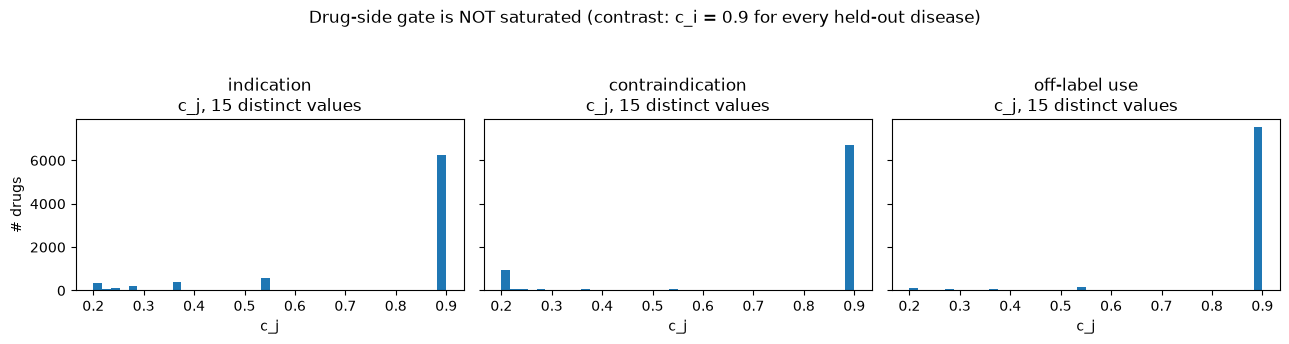

In [11]:
# gate distribution: c_j = exp_lambda_drug * exp(-exp_lambda_drug * dd_degree) + 0.2
from txgnn.utils import exponential

fig, axes = plt.subplots(1, len(DD_REL), figsize=(13, 3.2), sharey=True)
for ax, rel in zip(np.atleast_1d(axes), DD_REL):
    et = ('drug', rel, 'disease')
    if et not in G_cpu.edge_types:
        ax.set_title(f'{rel}\n(absent)'); continue
    deg = degree(G_cpu[et].edge_index[0], num_nodes=num_drugs)
    c_j = exponential(deg, DRUG_CFG['exp_lambda_drug']).numpy()
    ax.hist(c_j, bins=40)
    ax.set_title(f'{rel}\nc_j, {len(np.unique(c_j.round(4)))} distinct values')
    ax.set_xlabel('c_j')
np.atleast_1d(axes)[0].set_ylabel('# drugs')
plt.suptitle('Drug-side gate is NOT saturated (contrast: c_i = 0.9 for every held-out disease)', y=1.06)
plt.tight_layout(); plt.show()

---
## 5 · Baseline-integrity check — is `p_A` still the original TxGNN?

Everything downstream is a comparison against `p_A`. If enabling the drug module perturbs
the baseline, every number in §9 is meaningless. Two ways it could have been perturbed:

1. **RNG consumption.** A new `nn.Parameter` inside `DistMultPredictor.__init__` would
   shift every subsequent draw — `w_rels`, and the frozen Xavier node embeddings that *are*
   part of the model. Test: build two models from the same seed, one `drug_proto=False`,
   one `True`, and compare every parameter tensor.
2. **Forward-pass interference.** Test: score the same edges under `score_path='A'` with
   the drug module built, and compare against a model built without it.

### The two claims are not equally strong, and pretending otherwise is the error

**Weights: bit-for-bit.** `torch.equal`, no tolerance. This is the load-bearing claim —
a model *is* its parameters, and if these match, the drug module provably consumed no RNG.

**Outputs: within the non-determinism floor.** This one *cannot* be bit-for-bit on a GPU.
TxGNN aggregates neighbours with `torch_scatter`'s `reduce='mean'`, which accumulates via
atomic floating-point adds; thread scheduling decides the summation order, and float
addition is not associative. **Two forward passes through the same unmodified model
disagree in the last few bits.** An earlier version of this section asserted
`torch.equal` on the scores and failed for exactly that reason — with the drug module
deleted it would have failed too.

So the tolerance is **measured, not assumed**: run the same model twice, take the
disagreement as the floor, and require that off-module vs on-module sits at or below it.
On CPU the floor is exactly 0 and the test stays exact.

That floor is worth reading in its own right — it is the precision limit of every
comparison in this notebook, and part of what §9 calls "cross-seed variance" is this
wobble rather than the seed.

In [12]:
def build(seed, drug_cfg):
    set_all_seeds(seed)
    m = TxGNN(data=txdata, weight_bias_track=False, exp_name='integrity', device=DEVICE)
    m.model_initialize(**MODEL_CFG, **drug_cfg)
    return m

OFF = dict(drug_proto=False)

m_off = build(INIT_SEEDS[0], OFF)

# TxGNN.__init__ does `self.G = data.G` and model_initialize mutates G[nt].inp IN PLACE,
# so both models end up pointing at the same graph object. Snapshot now -- comparing
# m_off.G to m_on.G after the second build compares an object with itself and always
# "passes".
emb_off = {nt: m_off.G[nt].inp.detach().cpu().clone() for nt in m_off.G.node_types}
sd_off  = {k: v.detach().cpu().clone() for k, v in m_off.model.state_dict().items()}

m_on = build(INIT_SEEDS[0], DRUG_CFG)
sd_on = {k: v.detach().cpu().clone() for k, v in m_on.model.state_dict().items()}

# --- 1. parameter identity: exact, no tolerance ----------------------------------
assert set(sd_off) == set(sd_on), set(sd_on) ^ set(sd_off)
bad = [k for k in sd_off if not torch.equal(sd_off[k], sd_on[k])]
print('parameter tensors compared   : %d' % len(sd_off))
print('tensors that differ          : %d' % len(bad))
assert not bad, 'drug module perturbed the baseline weights: %s' % bad

emb_bad = [nt for nt in emb_off
           if not torch.equal(emb_off[nt], m_on.G[nt].inp.detach().cpu())]
print('frozen node embeddings differ: %d / %d node types' % (len(emb_bad), len(emb_off)))
assert not emb_bad, 'frozen embeddings perturbed: %s' % emb_bad

print('\nDR2 holds: the drug module consumes no torch RNG. Weights are bit-for-bit.')

parameter tensors compared   : 202
tensors that differ          : 0
frozen node embeddings differ: 0 / 10 node types

DR2 holds: the drug module consumes no torch RNG. Weights are bit-for-bit.


In [13]:
# --- 2. forward equivalence, measured against the non-determinism floor -----------
def score_test_edges(m):
    m.model.eval()
    Gd = m.G.to(DEVICE)
    with torch.no_grad():
        pos, _, _, _ = m.model(Gd, m.g_test_neg, m.g_test_pos,
                               pretrain_mode=False, mode='test')
    return {k: v.detach().cpu().clone() for k, v in pos.items()}


def max_delta(a, b):
    assert set(a) == set(b)
    return max(float((a[k] - b[k]).abs().max()) for k in a)


# CONTROL: the same model, scored repeatedly. On CUDA torch_scatter's reduce='mean'
# accumulates with atomic floats, so this is NOT zero -- it is the precision floor below
# which "identical" cannot be measured. On CPU it is exactly 0 and the test stays exact.
FLOOR_REPEATS = 3
s_off = score_test_edges(m_off)
floor = max(max_delta(s_off, score_test_edges(m_off)) for _ in range(FLOOR_REPEATS))
scale = max(float(v.abs().max()) for v in s_off.values())

m_on.set_score_path('A')
delta_A = max_delta(s_off, score_test_edges(m_on))

print('score magnitude (max |score|)          : %.4e' % scale)
print('non-determinism floor, same model twice: %.4e   (%.2e relative)'
      % (floor, floor / scale))
print('p_A  module-off vs module-on           : %.4e   (%.2e relative)'
      % (delta_A, delta_A / scale))

tol = floor * 10 if floor > 0 else 0.0
if floor == 0:
    print('\nfloor is exactly 0 (deterministic backend) -- requiring exact equality')
assert delta_A <= tol, (
    'score_path A diverged from the baseline by %.3e, which is %.1fx the measured '
    'non-determinism floor of %.3e. That is a real difference, not float noise.'
    % (delta_A, delta_A / max(floor, 1e-30), floor))
print('\np_A is the original TxGNN, to the limit of what this backend can measure.')

# --- 3. and path B must actually do something ------------------------------------
m_on.set_score_path('B')
delta_B = max_delta(s_off, score_test_edges(m_on))
m_on.set_score_path('A')

print('\np_B vs p_A                             : %.4e   (%.0fx the floor)'
      % (delta_B, delta_B / max(floor, 1e-30)))
assert delta_B > max(floor * 100, 1e-6), \
    'path B sits within the noise floor of path A -- the drug module is a no-op'
print('Path B is genuinely a different read-out.')

NONDET_FLOOR = floor      # reused in §9 to bound how much of the variance is noise

del m_off, m_on, sd_off, sd_on, emb_off
if torch.cuda.is_available():
    torch.cuda.empty_cache()

score magnitude (max |score|)          : 1.0718e-01
non-determinism floor, same model twice: 3.7253e-08   (3.48e-07 relative)
p_A  module-off vs module-on           : 3.7253e-08   (3.48e-07 relative)

p_A is the original TxGNN, to the limit of what this backend can measure.

p_B vs p_A                             : 7.8053e-02   (2095227x the floor)
Path B is genuinely a different read-out.


---
## 6 · One seed end to end

Train once on the unmodified path A (**DR1**), then read out both paths from that same
trained encoder. Drug pooling is parameter-free, so `p_B` needs no additional training —
it is a different way of *reading* the model, not a different model.

In [14]:
def train_one_seed(seed, drug_cfg=None, profile=None):
    '''Train on path A only. Returns a fitted TxGNN.'''
    drug_cfg = DRUG_CFG if drug_cfg is None else drug_cfg
    prof     = _PROFILES[PROFILE] if profile is None else profile

    set_all_seeds(seed)
    m = TxGNN(data=txdata, weight_bias_track=False,
              exp_name=f'dualrank_{SPLIT}_seed{seed}', device=DEVICE)
    m.model_initialize(**MODEL_CFG, **drug_cfg)
    m.set_score_path('A')                       # training is always the baseline path

    if prof['pretrain']['n_epoch'] > 0:
        set_all_seeds(seed); m.pretrain(**prof['pretrain'])
    set_all_seeds(seed); m.finetune(**prof['finetune'])
    return m


def eval_path(m, path):
    '''Disease-centric evaluation under one score path.

    Uses utils.disease_centric_evaluation unchanged (return_raw=True gives both the raw
    per-drug scores the fusion needs and the library's own per-disease metrics, which
    DR12 asserts against).
    '''
    m.set_score_path(path)
    ev = TxEval(model=m)
    out = ev.eval_disease_centric(disease_idxs='test_set', relation=None,
                                  save_result=False, show_plot=False, verbose=False,
                                  return_raw=True, simulate_random=False)
    m.set_score_path('A')
    return out

In [15]:
seed0 = INIT_SEEDS[0]
t0 = time.time()
m0 = train_one_seed(seed0)
print('\ntraining took %.1f min' % ((time.time() - t0) / 60))

t0 = time.time()
raw_A = eval_path(m0, 'A')
print('path A eval took %.1f min' % ((time.time() - t0) / 60))

t0 = time.time()
raw_B = eval_path(m0, 'B')
print('path B eval took %.1f min' % ((time.time() - t0) / 60))

Creating minibatch pretraining dataloader...
Start pre-training with #param: 1015000
Epoch: 0 Step: 0 LR: 0.00100 Loss 0.6930, Pretrain Micro AUROC 0.5044 Pretrain Micro AUPRC 0.5164 Pretrain Macro AUROC 0.4535 Pretrain Macro AUPRC 0.5817
Epoch: 0 Step: 100 LR: 0.00100 Loss 0.6557, Pretrain Micro AUROC 0.6484 Pretrain Micro AUPRC 0.6209 Pretrain Macro AUROC 0.6565 Pretrain Macro AUPRC 0.7125
Epoch: 0 Step: 200 LR: 0.00100 Loss 0.6355, Pretrain Micro AUROC 0.6762 Pretrain Micro AUPRC 0.6457 Pretrain Macro AUROC 0.7082 Pretrain Macro AUPRC 0.7611
Epoch: 0 Step: 300 LR: 0.00100 Loss 0.6301, Pretrain Micro AUROC 0.6806 Pretrain Micro AUPRC 0.6491 Pretrain Macro AUROC 0.7163 Pretrain Macro AUPRC 0.7499
Epoch: 0 Step: 400 LR: 0.00100 Loss 0.6177, Pretrain Micro AUROC 0.6928 Pretrain Micro AUPRC 0.6711 Pretrain Macro AUROC 0.6745 Pretrain Macro AUPRC 0.7409
Epoch: 0 Step: 500 LR: 0.00100 Loss 0.6177, Pretrain Micro AUROC 0.6931 Pretrain Micro AUPRC 0.6689 Pretrain Macro AUROC 0.6836 Pretrain 

  0%|          | 0/95 [00:00<?, ?it/s]

Evaluating relation: indication


  0%|          | 0/46 [00:00<?, ?it/s]

Evaluating relation: off-label use


...

Evaluating relation: indication


  0%|          | 0/46 [00:00<?, ?it/s]

Evaluating relation: off-label use


  0%|          | 0/31 [00:00<?, ?it/s]

path B eval took 0.6 min


### 6.1 The drug-relation id sets

`utils.calculate_metrics` restricts each disease's candidate list to the drugs that
participate in that relation anywhere in the full KG (`drug_ids_rels[rel]`), then drops
the `-1` train sentinels. `dual_rank.filter_candidates` mirrors this, so it needs the
same sets. Rebuilt here from `txdata.df` rather than re-reading the 1 GB `kg.csv`.

In [16]:
REL_DRUG_IDS = {'rev_' + r: _df[_df.relation == r].x_id.unique() for r in DD_REL}
for k, v in REL_DRUG_IDS.items():
    print('%-26s %6d drugs' % (k, len(v)))

rev_indication               1798 drugs
rev_contraindication         1262 drugs
rev_off-label use             477 drugs


### 6.2 Kill criterion — are `p_A` and `p_B` actually different?

Rank correlation between the two paths, per disease. **This decides whether §8 is worth
running.**

A fusion combines information only to the extent its inputs disagree. If the median
Spearman ρ is very high (say > 0.95), `p_B` is a monotone restatement of `p_A`, rank
averaging is arithmetic on one signal, and the five-seed sweep would buy nothing. Stop
here and report that instead.

The opposite failure also matters: ρ near zero with `p_B` AUPRC near chance means `p_B`
is noise, and averaging noise into `p_A` will lower the mean. The useful regime is
moderate correlation with `p_B` individually informative.

In [17]:
tab0 = pd.concat([
    dr.evaluate_variants(
        preds_a      = raw_A['prediction']['rev_' + r],
        preds_b      = raw_B['prediction']['rev_' + r],
        labels       = raw_A['label']['rev_' + r],
        rel_drug_ids = REL_DRUG_IDS['rev_' + r],
        degrees      = DEGREES[r],
        relation     = r, seed = seed0, split = SPLIT,
        keep_ids     = ZERO_SHOT_IDS,
    ) for r in DD_REL
], ignore_index=True)

# DR12: the p_A column must reproduce the library exactly, or nothing below is comparable
for r in DD_REL:
    lib_df = pd.DataFrame.from_dict(raw_A['result']['rev_' + r])
    worst = dr.assert_matches_library(tab0, lib_df, r)
    print('%-18s p_A matches library, max |delta| = %.2e' % (r, worst))

print()
rho = tab0[tab0.variant == 'p_A'].groupby('relation').spearman_A_B.describe()[['25%', '50%', '75%']]
print('Spearman rho between p_A and p_B rankings, per disease:')
print(rho.to_string())

med = tab0.spearman_A_B.median()
print('\noverall median rho: %.3f' % med)
if med > 0.95:
    print('\n>>> KILL CRITERION HIT. p_B is a monotone restatement of p_A -- fusion has')
    print('>>> nothing to combine. Do NOT enable RUN_MULTISEED; report this instead.')
else:
    print('\nPaths disagree enough for a fusion to be meaningful. Proceed to §7.')

indication         p_A matches library, max |delta| = 0.00e+00
contraindication   p_A matches library, max |delta| = 0.00e+00
off-label use      p_A matches library, max |delta| = 0.00e+00

Spearman rho between p_A and p_B rankings, per disease:
                       25%       50%       75%
relation                                      
contraindication  0.223343  0.384533  0.555024
indication       -0.036249  0.156617  0.491091
off-label use     0.132061  0.423279  0.560079

overall median rho: 0.354

Paths disagree enough for a fusion to be meaningful. Proceed to §7.


---
## 7 · Rank-average fusion (stage 1)

The no-training fusion: rank the candidates under each path, average the two ranks, rank
again. Invariant to score scale, which matters because `p_A` and `p_B` are DistMult
scores from differently-pooled embeddings and there is no reason for their magnitudes to
be commensurate.

`dual_rank.evaluate_variants` already computed it. AUPRC below is the library's
disease-centric flavour — ~2,000 candidate drugs per disease against a handful of
positives, so a random baseline is ~0.003 (baseline notebook §11.6). Do not compare
these to the paper's 0.89; that is the edge-level metric on a 1:1 negative set.

In [18]:
def variant_summary(tab):
    '''Macro AUPRC per (relation, variant), sentinel -1 rows dropped (baseline D8).'''
    v = tab[tab.auprc >= 0]
    return (v.pivot_table(index='variant', columns='relation', values='auprc', aggfunc='mean')
             .reindex(['p_A', 'p_B', 'fuse_rankavg', 'fuse_scalar', 'fuse_mlp'])
             .dropna(how='all'))

s0 = variant_summary(tab0)
print('seed %d -- macro AUPRC per relation\n' % seed0)
print(s0.round(4).to_string())
print()
delta = (s0.loc['fuse_rankavg'] - s0.loc['p_A'])
print('fuse_rankavg - p_A:')
print(delta.round(4).to_string())

seed 1 -- macro AUPRC per relation

relation      contraindication  indication  off-label use
variant                                                  
p_A                     0.0934      0.0225         0.0722
p_B                     0.0352      0.0108         0.0174
fuse_rankavg            0.0577      0.0381         0.0397

fuse_rankavg - p_A:
relation
contraindication   -0.0357
indication          0.0156
off-label use      -0.0326


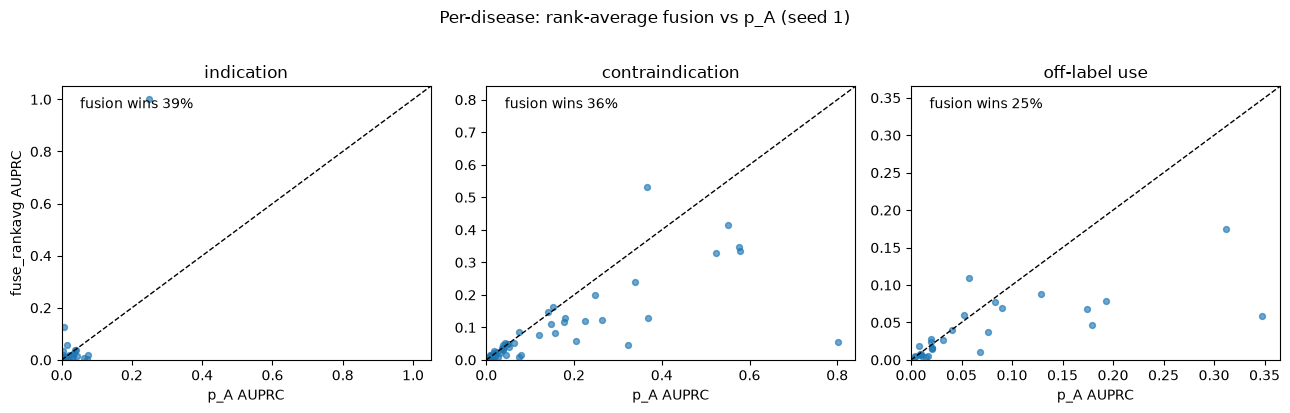

In [19]:
# per-disease paired view: does fusion help the diseases p_A does worst on?
piv = (tab0[tab0.auprc >= 0]
       .pivot_table(index=['relation', 'disease_id'], columns='variant', values='auprc'))

fig, axes = plt.subplots(1, len(DD_REL), figsize=(13, 4))
for ax, r in zip(np.atleast_1d(axes), DD_REL):
    if r not in piv.index.get_level_values(0):
        continue
    d = piv.loc[r]
    ax.scatter(d['p_A'], d['fuse_rankavg'], s=18, alpha=.65)
    lim = [0, max(d[['p_A', 'fuse_rankavg']].max()) * 1.05]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('p_A AUPRC'); ax.set_title(r)
    won = (d['fuse_rankavg'] > d['p_A']).mean()
    ax.text(.05, .92, 'fusion wins %.0f%%' % (100 * won), transform=ax.transAxes)
np.atleast_1d(axes)[0].set_ylabel('fuse_rankavg AUPRC')
plt.suptitle('Per-disease: rank-average fusion vs p_A (seed %d)' % seed0, y=1.02)
plt.tight_layout(); plt.show()

---
## 8 · Multi-seed sweep

The actual experiment. `SPLIT_SEED` fixed, `INIT_SEEDS` varied — so the data is identical
across runs and only the model changes (§3.2). Each seed writes its own directory, so the
loop is resumable and completed seeds are skipped.

Per seed: one training run, two evaluation passes. **Evaluation cost doubles** relative
to the baseline notebook; training cost is unchanged.

Set `RUN_MULTISEED = True` in §2 — and check the §6.2 kill criterion first.

In [20]:
def run_seed(seed, drug_cfg=None, tag='varA'):
    sdir = OUT_ROOT / f'seed{seed}_{tag}'
    per_disease_csv = sdir / 'per_disease.csv'
    if per_disease_csv.exists():
        print(f'[seed {seed}/{tag}] cached -> {sdir}')
        return pd.read_csv(per_disease_csv)

    sdir.mkdir(parents=True, exist_ok=True)
    print(f'\n{"#"*74}\n# seed {seed}   tag={tag}\n{"#"*74}')

    t0 = time.time()
    m = train_one_seed(seed, drug_cfg=drug_cfg)
    train_s = time.time() - t0

    t0 = time.time()
    rA, rB = eval_path(m, 'A'), eval_path(m, 'B')
    eval_s = time.time() - t0

    tab = pd.concat([
        dr.evaluate_variants(
            preds_a      = rA['prediction']['rev_' + r],
            preds_b      = rB['prediction']['rev_' + r],
            labels       = rA['label']['rev_' + r],
            rel_drug_ids = REL_DRUG_IDS['rev_' + r],
            degrees      = DEGREES[r],
            relation     = r, seed = seed, split = SPLIT,
            keep_ids     = ZERO_SHOT_IDS,
        ) for r in DD_REL
    ], ignore_index=True)

    for r in DD_REL:
        dr.assert_matches_library(tab, pd.DataFrame.from_dict(rA['result']['rev_' + r]), r)

    tab['tag'] = tag
    tab.to_csv(per_disease_csv, index=False)
    # raw scores kept so fusion can be refitted without retraining (§10)
    with open(sdir / 'raw_scores.pkl', 'wb') as f:
        pickle.dump({'A': rA['prediction'], 'B': rB['prediction'], 'label': rA['label']}, f)
    with open(sdir / 'run_config.json', 'w') as f:
        json.dump({'seed': seed, 'tag': tag, 'split': SPLIT, 'split_seed': SPLIT_SEED,
                   'profile': PROFILE, 'model': MODEL_CFG,
                   'drug': drug_cfg or DRUG_CFG,
                   'train_seconds': train_s, 'eval_seconds': eval_s,
                   'torch': torch.__version__, 'pyg': torch_geometric.__version__},
                  f, indent=2, default=str)

    del m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return tab

In [21]:
if RUN_MULTISEED:
    tabs = [run_seed(s) for s in INIT_SEEDS]
    ALL = pd.concat(tabs, ignore_index=True)
    ALL.to_parquet(OUT_ROOT / 'per_disease_all.parquet', index=False)
    ALL.to_csv(OUT_ROOT / 'per_disease_all.csv', index=False)
    print('\nrows: %s   ->  %s' % (f'{len(ALL):,}', OUT_ROOT / 'per_disease_all.parquet'))
else:
    p = OUT_ROOT / 'per_disease_all.parquet'
    if p.exists():
        ALL = pd.read_parquet(p); print('loaded cached sweep:', p)
    else:
        ALL = tab0.assign(tag='varA')
        print('RUN_MULTISEED is False and no cached sweep found.')
        print('Using the single seed from §6 so §9 runs -- variance columns will be empty.')


##########################################################################
# seed 1   tag=varA
##########################################################################
Creating minibatch pretraining dataloader...
Start pre-training with #param: 1015000
Epoch: 0 Step: 0 LR: 0.00100 Loss 0.6930, Pretrain Micro AUROC 0.5044 Pretrain Micro AUPRC 0.5164 Pretrain Macro AUROC 0.4535 Pretrain Macro AUPRC 0.5817
Epoch: 0 Step: 100 LR: 0.00100 Loss 0.6557, Pretrain Micro AUROC 0.6484 Pretrain Micro AUPRC 0.6209 Pretrain Macro AUROC 0.6577 Pretrain Macro AUPRC 0.7155
Epoch: 0 Step: 200 LR: 0.00100 Loss 0.6355, Pretrain Micro AUROC 0.6763 Pretrain Micro AUPRC 0.6456 Pretrain Macro AUROC 0.7080 Pretrain Macro AUPRC 0.7611
Epoch: 0 Step: 300 LR: 0.00100 Loss 0.6302, Pretrain Micro AUROC 0.6806 Pretrain Micro AUPRC 0.6490 Pretrain Macro AUROC 0.7171 Pretrain Macro AUPRC 0.7504
Epoch: 0 Step: 400 LR: 0.00100 Loss 0.6178, Pretrain Micro AUROC 0.6925 Pretrain Micro AUPRC 0.6708 Pretrain Macro AUROC 0

  0%|          | 0/95 [00:00<?, ?it/s]

Evaluating relation: indication


  0%|          | 0/46 [00:00<?, ?it/s]

Evaluating relation: off-label use


...

Evaluating relation: indication


  0%|          | 0/46 [00:00<?, ?it/s]

Evaluating relation: off-label use


  0%|          | 0/31 [00:00<?, ?it/s]


rows: 2,250   ->  /home/dsls/Desktop/projects/BardiaSabbagh/txgnn-refactor/results/dual_rank/cardiovascular_splitseed1_full/per_disease_all.parquet


---
## 9 · Analysis — variance *and* mean

The primary question: **does fusion reduce cross-seed variance without costing accuracy?**

Both halves are reported together and neither is meaningful alone. A fusion that halves
the variance while dropping mean AUPRC has not stabilised the model, it has made it
worse more consistently.

### 9.1 Headline table

In [22]:
def headline(all_tab):
    v = all_tab[all_tab.auprc >= 0]
    # macro AUPRC per (seed, relation, variant), then mean/sd across seeds
    per_seed = v.groupby(['variant', 'relation', 'seed']).auprc.mean().reset_index()
    agg = per_seed.groupby(['variant', 'relation']).auprc.agg(
        mean='mean', sd='std', n_seeds='count').reset_index()
    return agg

H = headline(ALL)
order = [x for x in ['p_A', 'p_B', 'fuse_rankavg', 'fuse_scalar', 'fuse_mlp']
         if x in set(H.variant)]

for r in DD_REL:
    sub = H[H.relation == r].set_index('variant').reindex(order)
    if sub['mean'].isna().all():
        continue
    print('=== %s ===' % r)
    print(sub[['mean', 'sd', 'n_seeds']].round(4).to_string())
    if sub['n_seeds'].max() > 1 and not np.isnan(sub.loc['p_A', 'sd']):
        base_sd, base_mu = sub.loc['p_A', 'sd'], sub.loc['p_A', 'mean']
        for v_ in order:
            if v_ == 'p_A':
                continue
            print('   %-14s  sd %+6.1f%%   mean %+.4f'
                  % (v_, 100 * (sub.loc[v_, 'sd'] / base_sd - 1), sub.loc[v_, 'mean'] - base_mu))
    print()

=== indication ===
                mean      sd  n_seeds
variant                              
p_A           0.0365  0.0111        5
p_B           0.0113  0.0051        5
fuse_rankavg  0.0298  0.0119        5
   p_B             sd  -53.9%   mean -0.0252
   fuse_rankavg    sd   +7.3%   mean -0.0067

=== contraindication ===
                mean      sd  n_seeds
variant                              
p_A           0.0972  0.0026        5
p_B           0.0382  0.0040        5
fuse_rankavg  0.0635  0.0054        5
   p_B             sd  +53.1%   mean -0.0589
   fuse_rankavg    sd +106.9%   mean -0.0337

=== off-label use ===
                mean      sd  n_seeds
variant                              
p_A           0.0861  0.0187        5
p_B           0.0165  0.0021        5
fuse_rankavg  0.0464  0.0130        5
   p_B             sd  -89.0%   mean -0.0696
   fuse_rankavg    sd  -30.4%   mean -0.0397



### 9.2 Paired per-seed deltas

The variants share seeds *and* share a trained encoder, so the paired test is the right
one — exactly as `docs/dhgat_fails.md` argued for the arms of the earlier gate experiment.
An unpaired comparison would drown the effect in between-seed variance.

`seeds won` is the honest headline: an effect that is real should win on most seeds, not
squeak through on a mean.

In [23]:
def paired(all_tab, base='p_A'):
    v = all_tab[all_tab.auprc >= 0]
    per_seed = (v.groupby(['relation', 'variant', 'seed']).auprc.mean()
                 .unstack('variant'))
    rows = []
    for var in per_seed.columns:
        if var == base:
            continue
        d = (per_seed[var] - per_seed[base]).dropna()
        for r in d.index.get_level_values(0).unique():
            dd = d.loc[r]
            n = len(dd)
            ci = 1.96 * dd.std() / np.sqrt(n) if n > 1 else np.nan
            rows.append({'relation': r, 'comparison': f'{var} - {base}',
                         'delta_AUPRC': dd.mean(), 'ci95': ci,
                         'seeds_won': f'{int((dd > 0).sum())} / {n}'})
    return pd.DataFrame(rows)

P = paired(ALL)
if len(P) and P.ci95.notna().any():
    print(P.round(4).to_string(index=False))
else:
    print('Needs >1 seed. Enable RUN_MULTISEED in §2.')

        relation         comparison  delta_AUPRC   ci95 seeds_won
contraindication fuse_rankavg - p_A      -0.0337 0.0030     0 / 5
      indication fuse_rankavg - p_A      -0.0067 0.0171     2 / 5
   off-label use fuse_rankavg - p_A      -0.0397 0.0193     0 / 5
contraindication          p_B - p_A      -0.0589 0.0026     0 / 5
      indication          p_B - p_A      -0.0252 0.0112     0 / 5
   off-label use          p_B - p_A      -0.0696 0.0174     0 / 5


### 9.3 Where the variance lives — stratified by `kg_degree`

The original hypothesis was that instability concentrates in sparse diseases. `kg_degree`
(not `dd_degree_train`, which is 0 for every held-out disease — §3.5) is the stratifier.

If fusion works the way the hypothesis predicts, the variance reduction should be
**largest in the low-degree bins**. If it is flat across bins, fusion is doing something
real but not what the hypothesis says.

In [24]:
def stratified(all_tab, n_bins=4):
    v = all_tab[(all_tab.auprc >= 0) & all_tab.kg_degree.notna()].copy()
    if v.seed.nunique() < 2:
        return None
    try:
        v['deg_bin'] = pd.qcut(v.kg_degree, n_bins, duplicates='drop')
    except ValueError:
        return None
    # per-disease variance across seeds, then averaged within a bin
    per_dis = (v.groupby(['relation', 'variant', 'deg_bin', 'disease_id'], observed=True)
                .auprc.agg(['mean', 'std', 'count']).reset_index())
    per_dis = per_dis[per_dis['count'] > 1]
    return (per_dis.groupby(['relation', 'variant', 'deg_bin'], observed=True)
                   .agg(mean_auprc=('mean', 'mean'),
                        mean_sd_across_seeds=('std', 'mean'),
                        n_diseases=('disease_id', 'nunique')).reset_index())

S = stratified(ALL)
if S is None:
    print('Needs >1 seed. Enable RUN_MULTISEED in §2.')
else:
    S.to_csv(OUT_ROOT / 'degree_stratified.csv', index=False)
    for r in DD_REL:
        sub = S[S.relation == r]
        if sub.empty:
            continue
        print('=== %s ===' % r)
        print(sub.pivot_table(index='deg_bin', columns='variant',
                              values='mean_sd_across_seeds', observed=True)
                 .round(4).to_string())
        print()
    print('(values are mean per-disease SD across seeds -- lower is more stable)')

=== indication ===
variant        fuse_rankavg     p_A     p_B
deg_bin                                    
(-0.001, 3.0]        0.0051  0.0020  0.0013
(3.0, 8.0]           0.0055  0.0247  0.0023
(8.0, 28.0]          0.0084  0.0054  0.0024
(28.0, 216.0]        0.0389  0.0398  0.0154

=== contraindication ===
variant        fuse_rankavg     p_A     p_B
deg_bin                                    
(-0.001, 3.0]        0.0054  0.0090  0.0055
(3.0, 8.0]           0.0079  0.0092  0.0050
(8.0, 28.0]          0.0235  0.0262  0.0142
(28.0, 216.0]        0.0206  0.0147  0.0073

=== off-label use ===
variant        fuse_rankavg     p_A     p_B
deg_bin                                    
(-0.001, 3.0]        0.0122  0.0181  0.0027
(3.0, 8.0]           0.0304  0.0267  0.0040
(8.0, 28.0]          0.0297  0.0779  0.0046
(28.0, 216.0]        0.0328  0.0326  0.0102

(values are mean per-disease SD across seeds -- lower is more stable)


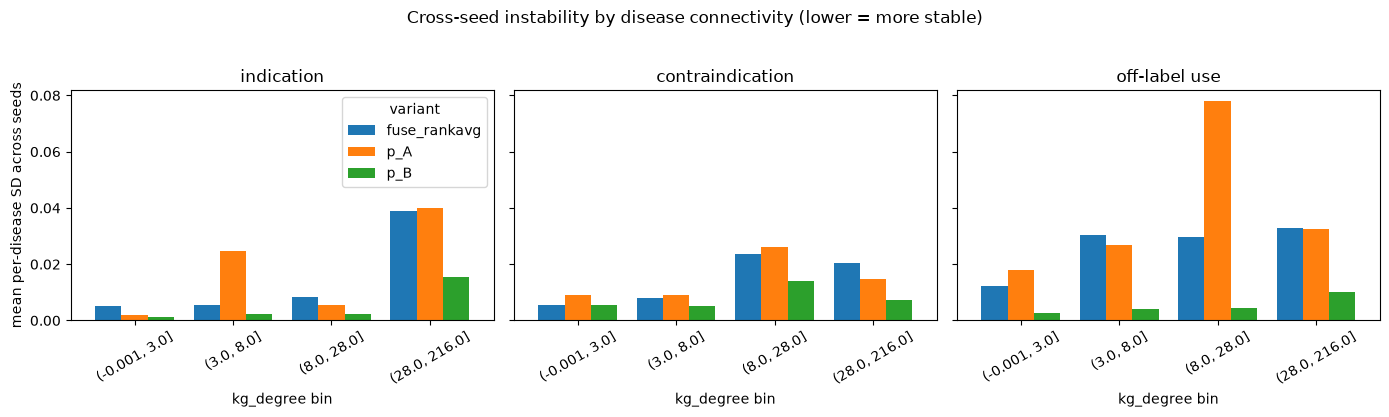

In [25]:
if S is not None:
    fig, axes = plt.subplots(1, len(DD_REL), figsize=(14, 4), sharey=True)
    for ax, r in zip(np.atleast_1d(axes), DD_REL):
        sub = S[S.relation == r]
        if sub.empty:
            continue
        pv = sub.pivot_table(index='deg_bin', columns='variant',
                             values='mean_sd_across_seeds', observed=True)
        pv.plot(kind='bar', ax=ax, legend=(r == DD_REL[0]), width=.8)
        ax.set_title(r); ax.set_xlabel('kg_degree bin')
        ax.tick_params(axis='x', rotation=30)
    np.atleast_1d(axes)[0].set_ylabel('mean per-disease SD across seeds')
    plt.suptitle('Cross-seed instability by disease connectivity (lower = more stable)', y=1.03)
    plt.tight_layout(); plt.show()

---
## 10 · Stage 2 — learned late fusion

Only worth running if §9 shows rank averaging doing something. Two extra evaluation
passes per seed are needed, because the fusion has to be fitted on **validation**
diseases (**DR13**) — fitting on the test diseases would leak.

Two models, both outside TxGNN (**DR3**):

* **scalar** — `w·z(p_A) + (1-w)·z(p_B)`, one parameter, grid-searched. Robust, and if
  the fitted `w` lands at 0 or 1 that is itself the answer: one path carries everything.
* **MLP** — 2 layers on `[z_A, z_B, rank%_A, rank%_B, dd_degree_train, kg_degree]`. The
  degree columns are constant within a disease, which is the point: they let the mixing
  weight be *degree-conditional*, which is the only reason to prefer this over the scalar.

Set `RUN_LEARNED_FUSION = True` in §2.

In [26]:
def validation_rows(m, seed):
    '''Score the validation diseases under both paths, for fitting the fusion.'''
    val_dis = (txdata.df_valid[txdata.df_valid.relation.isin(['rev_' + r for r in DD_REL])]
               .x_idx.unique())
    if len(val_dis) == 0:
        raise RuntimeError('no validation diseases with drug-disease edges')

    rows, feats, labs = [], [], []
    val_deg = build_degree_table(txdata.G.to('cpu'), sorted(val_dis))
    for r in DD_REL:
        for path, store in (('A', {}), ('B', {})):
            m.set_score_path(path)
            ev = TxEval(model=m)
            store['out'] = ev.eval_disease_centric(
                disease_idxs=val_dis, relation=r, save_result=False, show_plot=False,
                verbose=False, return_raw=True, simulate_random=False)
            if path == 'A':
                oA = store['out']
            else:
                oB = store['out']
        m.set_score_path('A')

        for did in oA['prediction']:
            _, pa, lab = dr.filter_candidates(oA['prediction'][did], oA['label'][did],
                                              REL_DRUG_IDS['rev_' + r])
            _, pb, _ = dr.filter_candidates(oB['prediction'][did], oA['label'][did],
                                            REL_DRUG_IDS['rev_' + r])
            if (lab == 1).sum() == 0:
                continue
            d = val_deg[r].get(did, {})
            rows.append((pa, pb, lab))
            feats.append(dr.build_fusion_features(pa, pb, d.get('dd_degree_train', 0),
                                                  d.get('kg_degree', 0)))
            labs.append(lab)
    return rows, feats, labs

In [27]:
if RUN_LEARNED_FUSION:
    fused_tabs = []
    for seed in INIT_SEEDS:
        sdir = OUT_ROOT / f'seed{seed}_varA'
        m = train_one_seed(seed)                      # cached checkpoints are not kept; retrains
        rows, feats, labs = validation_rows(m, seed)

        w, w_score = dr.fit_scalar_weight(rows)
        mlp, norm  = dr.fit_mlp_fusion(feats, labs, seed=seed)
        print(f'[seed {seed}] fitted scalar w = {w:.2f}  (val macro AUPRC {w_score:.4f})')

        with open(sdir / 'raw_scores.pkl', 'rb') as f:
            raw = pickle.load(f)
        tab = pd.concat([
            dr.evaluate_variants(
                preds_a=raw['A']['rev_' + r], preds_b=raw['B']['rev_' + r],
                labels=raw['label']['rev_' + r], rel_drug_ids=REL_DRUG_IDS['rev_' + r],
                degrees=DEGREES[r], relation=r, seed=seed, split=SPLIT,
                keep_ids=ZERO_SHOT_IDS, fusion={'w': w, 'mlp': mlp, 'norm': norm},
            ) for r in DD_REL], ignore_index=True)
        tab['tag'] = 'varA'
        tab['fusion_w'] = w
        tab.to_csv(sdir / 'per_disease_fused.csv', index=False)
        fused_tabs.append(tab)

        del m
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    ALL = pd.concat(fused_tabs, ignore_index=True)
    ALL.to_parquet(OUT_ROOT / 'per_disease_all_fused.parquet', index=False)
    print('\nRe-run §9 with the learned variants included.')
else:
    print('RUN_LEARNED_FUSION is False -- stage 2 skipped.')

Creating minibatch pretraining dataloader...
Start pre-training with #param: 1015000
Epoch: 0 Step: 0 LR: 0.00100 Loss 0.6930, Pretrain Micro AUROC 0.5044 Pretrain Micro AUPRC 0.5164 Pretrain Macro AUROC 0.4535 Pretrain Macro AUPRC 0.5817
Epoch: 0 Step: 100 LR: 0.00100 Loss 0.6557, Pretrain Micro AUROC 0.6484 Pretrain Micro AUPRC 0.6209 Pretrain Macro AUROC 0.6565 Pretrain Macro AUPRC 0.7125
Epoch: 0 Step: 200 LR: 0.00100 Loss 0.6355, Pretrain Micro AUROC 0.6763 Pretrain Micro AUPRC 0.6456 Pretrain Macro AUROC 0.7079 Pretrain Macro AUPRC 0.7609
Epoch: 0 Step: 300 LR: 0.00100 Loss 0.6302, Pretrain Micro AUROC 0.6806 Pretrain Micro AUPRC 0.6493 Pretrain Macro AUROC 0.7169 Pretrain Macro AUPRC 0.7516
Epoch: 0 Step: 400 LR: 0.00100 Loss 0.6178, Pretrain Micro AUROC 0.6927 Pretrain Micro AUPRC 0.6712 Pretrain Macro AUROC 0.6743 Pretrain Macro AUPRC 0.7409
Epoch: 0 Step: 500 LR: 0.00100 Loss 0.6173, Pretrain Micro AUROC 0.6934 Pretrain Micro AUPRC 0.6691 Pretrain Macro AUROC 0.6833 Pretrain 

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

### 10.3 `exp_lambda_drug` sweep

The one hyperparameter genuinely new to this work, and there is no reason the disease
side's 0.7 transfers (**DR14**).

This is cheap in a way retraining is not: the drug gate is applied at *forward* time and
the pooling has no parameters, so a new λ needs one extra evaluation pass and **no
retraining**. λ controls how fast the gate decays with drug degree —
`c_j = λ·e^(−λ·deg) + 0.2` — so small λ means even well-connected drugs keep borrowing,
large λ means only the rarest do.

In [ ]:
if RUN_LAMBDA_SWEEP:
    LAMBDAS = [0.1, 0.3, 0.5, 0.7, 1.0, 2.0]
    m = train_one_seed(INIT_SEEDS[0])
    out = []
    for lam in LAMBDAS:
        m.model.pred.exp_lambda_drug = lam       # gate is applied at forward time
        m.best_model.pred.exp_lambda_drug = lam
        rB = eval_path(m, 'B')
        t = pd.concat([
            dr.evaluate_variants(
                preds_a=raw_A['prediction']['rev_' + r], preds_b=rB['prediction']['rev_' + r],
                labels=raw_A['label']['rev_' + r], rel_drug_ids=REL_DRUG_IDS['rev_' + r],
                degrees=DEGREES[r], relation=r, seed=INIT_SEEDS[0], split=SPLIT,
                keep_ids=ZERO_SHOT_IDS,
            ) for r in DD_REL], ignore_index=True)
        s = variant_summary(t)
        out.append({'lambda_drug': lam,
                    **{f'p_B_{r}': s.loc['p_B', r] for r in s.columns},
                    **{f'fuse_{r}': s.loc['fuse_rankavg', r] for r in s.columns}})
        print('lambda=%.2f done' % lam)
    L = pd.DataFrame(out)
    L.to_csv(OUT_ROOT / 'lambda_drug_sweep.csv', index=False)
    print(); print(L.round(4).to_string(index=False))
    del m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print('RUN_LAMBDA_SWEEP is False -- skipped.')

---
## 11 · Stage 3 — variant (b) ablation

`drug_sim_measure='drug_all_profile'` concatenates `drug_drug` with `drug_protein`,
mirroring the disease side's two-block signature literally.

The prediction from §4.2 is that it will be **worse**, because `drug_drug` outweighs
`drug_protein` by roughly two orders of magnitude in degree and the cosine will track
co-prescription rather than mechanism. Worth measuring rather than asserting — and note
`docs/dhgat_fails.md` found the analogous change on the disease side (splitting the
signature into separately-compared blocks) cost −0.0305 macro AUPRC on 5/5 seeds. Prior
evidence, not proof: that experiment changed how blocks were *compared*, this one changes
which blocks are *present*.

Set `RUN_VARIANT_B = True` in §2, and only after stage 1 has produced results.

In [ ]:
if RUN_VARIANT_B:
    DRUG_CFG_B = {**DRUG_CFG, 'drug_sim_measure': 'drug_all_profile'}
    tabs_b = [run_seed(s, drug_cfg=DRUG_CFG_B, tag='varB') for s in INIT_SEEDS]
    ALL_B = pd.concat(tabs_b, ignore_index=True)
    ALL_B.to_parquet(OUT_ROOT / 'per_disease_all_varB.parquet', index=False)

    both = pd.concat([ALL.assign(tag='varA'), ALL_B], ignore_index=True)
    cmp_ = (both[both.auprc >= 0]
            .groupby(['tag', 'variant', 'relation', 'seed']).auprc.mean().reset_index()
            .groupby(['tag', 'variant', 'relation']).auprc.agg(['mean', 'std']))
    print(cmp_.round(4).to_string())
else:
    print('RUN_VARIANT_B is False -- ablation skipped. Run stage 1 first.')

---
## 12 · Caveats — what this does and does not show

**`p_B` is a read-out, not a trained model (DR1).** The encoder never saw drug pooling
during training, so `p_B` alone is expected to be weaker than `p_A`. That is not a
failure of the idea; an ensemble member needs to be *decorrelated*, not individually
strong. But it does mean a negative result here does not close the door on drug-side
pooling as a *trained* component — that is a different experiment, reachable by training
under `score_path='B'`, and it would forfeit the bit-for-bit baseline.

**The disease-side gate is inert at evaluation time.** In any zero-shot split, held-out
diseases have `dd_degree_train = 0`, so `c_i = 0.9` uniformly (§3.5). TxGNN's rarity
gate does not differentiate the diseases the zero-shot benchmark scores; it differentiates
*training* diseases. Any story about sparse diseases leaning harder on borrowed signal has
to run through signature quality (`kg_degree`), not the gate. This is a property of the
published method, not of the port.

**Two AUPRCs, one name.** Everything here is the disease-centric ranking metric (~2,000
candidates, a handful of positives, random baseline ~0.003) — the paper's Supplementary
Figs. 9–11 family, not the edge-level 0.89 in Fig. 2d. Baseline notebook §11.6.

**5 seeds.** Enough for effects the size of the DHGAT experiment's (CIs excluding zero,
0/5 or 5/5 wins). Not enough to resolve a 0.005 difference. If §9's CIs straddle zero,
the answer is "no detectable effect at n=5", not "no effect".

**The usable test set is small, and smaller than the area file suggests.** `anemia`
lists 65 diseases; 15 have drug-disease edges in the test split; 13 survive the
zero-shot filter (§3.4). Degree-stratifying 13 diseases into four bins is ~3 per bin,
which will not support a claim about *where* variance concentrates. Either report §9.1
and §9.2 only, or move to a larger area (§3.4b) before drawing that conclusion.

**One split, one area.** `anemia`, 65 held-out diseases. Whether this generalises across
the other eight disease areas is unmeasured. `neurodigenerative` (68) and `autoimmune`
(55) are the natural next checks; `cell_proliferation` (598) is the expensive one.

**Non-determinism floor.** `torch_scatter`'s `reduce='mean'` uses non-deterministic CUDA
atomics, so even a fully fixed seed drifts between runs — two forward passes through the
same model disagree in the last bits. §5 now **measures** this (`NONDET_FLOOR`) by scoring
one model repeatedly, and every equivalence claim in this notebook is stated relative to
it rather than as bitwise equality. Read §9's variance numbers against that floor: a
variance reduction of the same order as the floor is not evidence of anything. The floor
is measured at the score level, not the AUPRC level, so it is a lower bound on the noise
in §9, not a direct subtraction.

**`exp_lambda` was silently reverting.** `TxGNN.save_model` omitted it from `self.config`,
so `load_pretrained` reset any non-default value to 0.7. Fixed as part of this work
(§0). It affects any earlier run that set a non-default `exp_lambda` and then reloaded —
none in this repo do, so no published number changes.